<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/House_Price_Prediction_%26_Classification_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Learning Practice Worksheet House Price Prediction & Classification

Practice Dataset: house_price_prediction.csv
Data Exploration & Preprocessing
1. Load the dataset.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving house_price_prediction_dataset.csv to house_price_prediction_dataset.csv


In [23]:
import pandas as pd

import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split


from sklearn.linear_model import LinearRegression

from sklearn.linear_model import LogisticRegression


from sklearn.preprocessing import PolynomialFeatures


from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score

Q1. Explore the Dataset  Write the code to: ● Display the first five rows. ● Find the number of rows and columns. ● Check the data types. ● Display summary statistics.

In [3]:
df = pd.read_csv("house_price_prediction_dataset.csv")

In [4]:
df.head()

,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_years,Garage,Price_USD
0,H001,3319,4,3,23,1,548284
1,H002,1614,2,1,21,0,274509
2,H003,2428,3,2,2,0,430943
3,H004,2769,5,4,17,0,507522
4,H005,3361,6,5,7,1,634249


In [5]:
df.shape

(100, 7)

In [6]:
df.dtypes

,0
House_ID,object
Area_sqft,int64
Bedrooms,int64
Bathrooms,int64
Age_years,int64
Garage,int64
Price_USD,int64


In [7]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Garage,Price_USD
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000
mean,1962.540000,3.030000,2.410000,15.400000,0.57000,359562.600000
std,825.155173,1.226434,1.279954,9.474047,0.49757,142340.234661
min,739.000000,2.000000,1.000000,0.000000,0.00000,134337.000000
25%,1218.250000,2.000000,1.000000,7.000000,0.00000,235956.250000
50%,1819.000000,3.000000,2.000000,16.500000,1.00000,319309.500000
75%,2664.250000,4.000000,3.000000,23.000000,1.00000,476662.500000
max,3493.000000,6.000000,5.000000,30.000000,1.00000,651702.000000


Q2. Data Cleaning Answer the following: 1. Does the dataset contain any missing values? 2. Which column will be your target variable? 3. Which columns are features?

In [12]:
df.duplicated().sum()
df_clean = df.dropna()
# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

df_clean.shape

(100, 7)

In [ ]:
target_column = "Price_USD" # target
# Store the feature column names
feature_columns = [
    "Area_sqft",
    "Bedrooms",
    "Bathrooms",
    "Age_years",
    "Garage"
]

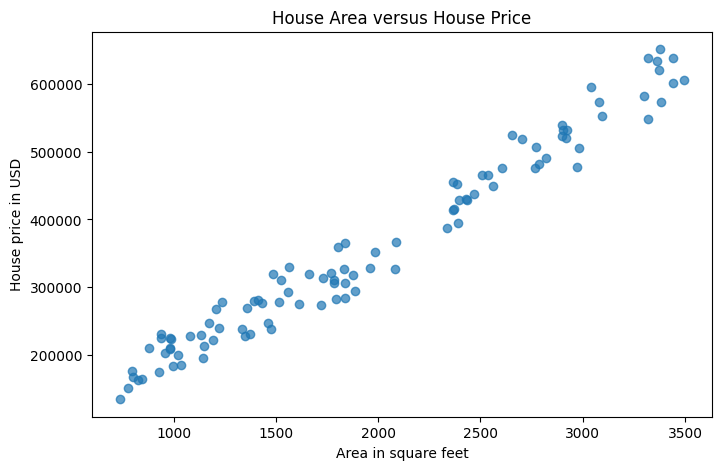

In [13]:
# Create a figure for the scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(df_clean["Area_sqft"],df_clean["Price_USD"],alpha=0.7)

plt.xlabel("Area in square feet")

plt.ylabel("House price in USD")

plt.title("House Area versus House Price")

plt.show()

Q3. Feature Engineering  Create a new feature named: Price_per_sqft Formula: Price_USD / Area_sqft Display the first five values.

In [14]:
df_clean["Price_per_sqft"] = (df_clean["Price_USD"] /df_clean["Area_sqft"])
df_clean["Price_per_sqft"].head()

,Price_per_sqft
0,165.195541
1,170.079926
2,177.488880
3,183.287107
4,188.708420


Q4. Feature Selection  Select the following features: ● Area_sqft ● Bedrooms ● Bathrooms ● Age_years ● Garage Store them in X and store Price_USD in y.

In [17]:
x = df_clean[["Area_sqft","Bedrooms","Bathrooms", "Age_years","Garage"]]
x.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Garage
0,3319,4,3,23,1
1,1614,2,1,21,0
2,2428,3,2,2,0
3,2769,5,4,17,0
4,3361,6,5,7,1


In [ ]:
y = df_clean["Price_USD"]
y.head()

Linear Regression Q5. Split the Dataset Split the data into: ● 80% Training ● 20% Testing

In [19]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.20,random_state=42)
print("X training shape:", X_train.shape)

print("X testing shape:", X_test.shape)

print("y training shape:", y_train.shape)

print("y testing shape:", y_test.shape)

X training shape: (80, 5)
X testing shape: (20, 5)
y training shape: (80,)
y testing shape: (20,)


Q6. Train a Linear Regression Model  Use Linear Regression to train the model. Predict prices for the testing data.

In [24]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
print(linear_predictions)

[211076.640024   512863.63747061 175750.21643256 468025.50525591
 362886.76243243 595978.76189247 209132.07025953 534844.55283181
 307459.49092308 559578.74821629 588564.31666568 159676.15476701
 223296.93418846 228528.85914178 457683.75469106 634681.82212514
 204661.40846338 284978.42443306 369568.85509604 219345.00971097]


Q7. Model Evaluation  Calculate: ● Mean Absolute Error (MAE) ● Mean Squared Error (MSE) ● R² Score Write one sentence describing your model's performance.

In [25]:
# Calculate the Mean Absolute Error
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)
# Calculate the Mean Squared Error
linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)
# Calculate the R² score
linear_r2 = r2_score(
    y_test,
    linear_predictions
)
print("Mean Absolute Error:", linear_mae)

print("Mean Squared Error:", linear_mse)

print("R² Score:", linear_r2)

Mean Absolute Error: 7705.5181800241435
Mean Squared Error: 80204901.65805602
R² Score: 0.9967906097137917


In [26]:
# Describe the performance according to the R² score
if linear_r2 >= 0.90:
    print("The Linear Regression model performed very well.")

elif linear_r2 >= 0.70:
    print("The Linear Regression model performed reasonably well.")

else:
    print("The Linear Regression model needs improvement.")

The Linear Regression model performed very well.


Q8. Make a Prediction Predict the price of a house with: ● Area = 2200 sqft ● Bedrooms = 4 ● Bathrooms = 3 ● Age = 6 years ● Garage = Yes Write the predicted price.

In [27]:
# Create a DataFrame containing the new house information
new_house = pd.DataFrame([ { "Area_sqft": 2200, "Bedrooms": 4, "Bathrooms": 3,"Age_years": 6,"Garage": 1} ])

# Prediction
predicted_house_price = linear_model.predict(new_house)
print("Predicted house price:", predicted_house_price[0])

Predicted house price: 431583.43326406897


Polynomial Regression Polynomial Regression can capture curved relationships.

Q9. Train a Polynomial Regression model with degree = 2. Answer: 1. Did the R² score improve compared to Linear Regression? 2. Which model performed better?

In [28]:
polynomial_features = PolynomialFeatures(degree=2,include_bias=False)
X_train_polynomial = polynomial_features.fit_transform(X_train)
X_test_polynomial = polynomial_features.transform(X_test)
polynomial_model = LinearRegression()
polynomial_model.fit(X_train_polynomial,y_train)
polynomial_predictions = polynomial_model.predict(X_test_polynomial)

In [29]:
# Calculate the Polynomial Regression Mean Absolute Error
polynomial_mae = mean_absolute_error(
    y_test,
    polynomial_predictions
)
# Calculate the Polynomial Regression Mean Squared Error
polynomial_mse = mean_squared_error(
    y_test,
    polynomial_predictions
)
# Calculate the Polynomial Regression R² score
polynomial_r2 = r2_score(
    y_test,
    polynomial_predictions
)

print("Polynomial Regression MAE:", polynomial_mae)

print("Polynomial Regression MSE:", polynomial_mse)

print("Polynomial Regression R²:", polynomial_r2)

Polynomial Regression MAE: 8337.23424222251
Polynomial Regression MSE: 87993813.31203395
Polynomial Regression R²: 0.9964789372737582


In [30]:
# Check whether Polynomial Regression improved the R² score
if polynomial_r2 > linear_r2:
    print("The Polynomial Regression R² score improved.")
    print("Polynomial Regression performed better.")

elif polynomial_r2 < linear_r2:
    print("The Polynomial Regression R² score did not improve.")
    print("Linear Regression performed better.")

else:
    print("Both models produced the same R² score.")

The Polynomial Regression R² score did not improve.
Linear Regression performed better.


Q10. Logistic Regression Train a Logistic Regression model using the same features. Calculate the model accuracy. Write the accuracy score.

In [31]:
median_price = df_clean["Price_USD"].median()
df_clean["Price_Category"] = (
    df_clean["Price_USD"] >= median_price
).astype(int)


The categories are:

0: price below the median

1: price equal to or above the median

In [32]:
X_classification = df_clean[["Area_sqft","Bedrooms","Bathrooms","Age_years","Garage"]]
y_classification = df_clean["Price_Category"]
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

In [33]:
logistic_model = Pipeline(
    steps=[( "scaler",StandardScaler()),("logistic_regression",LogisticRegression(max_iter=1000,random_state=42))])

logistic_model.fit(X_class_train,y_class_train)
logistic_predictions = logistic_model.predict(X_class_test)
logistic_accuracy = accuracy_score(y_class_test,logistic_predictions)
print("Logistic Regression accuracy:", logistic_accuracy)

Logistic Regression accuracy: 0.9
